# Segmentação de Tumores Cerebrais em MRI com U-Net

**Trabalho prático — Visão Computacional / Redes Neurais Profundas**

**Objetivo:** aplicar uma arquitetura de segmentação semântica (U-Net) para identificar,
em imagens de ressonância magnética (MRI) cerebral, a região correspondente a um
tumor de baixo grau (LGG — *Low-Grade Glioma*), um problema de **segmentação binária
de duas classes**: `tumor` vs. `fundo (tecido saudável)`.

**Dataset:** [LGG Segmentation Dataset](https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation)
(The Cancer Imaging Archive / TCGA) — 110 pacientes, 3.929 fatias de MRI (256×256, 3 canais:
pré-contraste, FLAIR, pós-contraste) cada uma com sua **máscara binária real** de anormalidade
FLAIR (região de tumor), anotada manualmente.

**Arquitetura escolhida:** U-Net — arquitetura clássica de segmentação biomédica, com
codificador convolucional, decodificador com upsampling e *skip connections* que preservam
detalhes espaciais finos, essenciais para delimitar bordas de lesões pequenas.

O projeto segue as 5 etapas propostas: (1) carregamento e análise do dataset,
(2) pré-processamento, (3) construção do modelo, (4) treinamento e validação,
(5) avaliação e interpretação.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "notebook").exists() is False and Path.cwd().name == "notebook" else Path.cwd()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

from manifest import build_manifest
from splits import patient_level_split
from dataset import BrainMRISegmentationDataset
from model import UNet
from losses import BCEDiceLoss, dice_coefficient, iou_score
from engine import evaluate
from utils import set_seed, denormalize

OUTPUTS = PROJECT_ROOT / "outputs"
set_seed(42)
print("Projeto:", PROJECT_ROOT)


Projeto: /home/leticia/dev/unisinos/redes-neurais-profunda-atividade-02


## Etapa 1 — Carregamento e análise do dataset

### 1.1 Organização dos dados

O dataset já vem organizado em 110 pastas (uma por paciente/exame), cada uma contendo pares
`<id>_<fatia>.tif` (imagem) e `<id>_<fatia>_mask.tif` (máscara). Um **manifesto**
(`build_manifest`) é construído varrendo essas pastas e associando cada imagem à sua máscara,
marcando também se a fatia contém ou não pixels de tumor (`has_tumor`).


In [2]:
manifest = build_manifest()
print(f"Total de fatias: {len(manifest)}")
print(f"Total de pacientes: {manifest.patient_id.nunique()}")
print(f"Fatias com tumor: {manifest.has_tumor.sum()} ({manifest.has_tumor.mean():.1%})")
print(f"Fatias sem tumor: {(~manifest.has_tumor).sum()} ({(~manifest.has_tumor).mean():.1%})")
manifest.head()


Total de fatias: 3929
Total de pacientes: 110
Fatias com tumor: 1373 (34.9%)
Fatias sem tumor: 2556 (65.1%)


,patient_id,image_path,mask_path,has_tumor,tumor_pixel_ratio
0,TCGA_CS_4941_19960909,datasets/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,datasets/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,False,0.000000
1,TCGA_CS_4941_19960909,datasets/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,datasets/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,False,0.000000
2,TCGA_CS_4941_19960909,datasets/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,datasets/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,True,0.021759
3,TCGA_CS_4941_19960909,datasets/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,datasets/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,True,0.040375
4,TCGA_CS_4941_19960909,datasets/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,datasets/kaggle_3m/TCGA_CS_4941_19960909/TCGA_...,True,0.042191


### 1.2 Divisão treino / validação / teste

A divisão é feita **por paciente** (não por fatia isolada): todas as fatias de um mesmo
paciente ficam no mesmo conjunto. Isso evita **vazamento de dados** — se fatias vizinhas do
mesmo exame fossem espalhadas entre treino e teste, o modelo "veria" indiretamente o paciente
de teste durante o treino (fatias adjacentes são muito parecidas), inflando artificialmente
as métricas. A divisão é estratificada por "paciente possui alguma fatia com tumor", mantendo
a proporção de casos positivos semelhante nos três conjuntos (~70/15/15%).


In [3]:
splits = patient_level_split(manifest)
resumo = []
for nome, df in splits.items():
    resumo.append({
        "conjunto": nome,
        "pacientes": df.patient_id.nunique(),
        "fatias": len(df),
        "% fatias com tumor": f"{df.has_tumor.mean():.1%}",
    })
pd.DataFrame(resumo)


,conjunto,pacientes,fatias,% fatias com tumor
0,train,77,2760,36.0%
1,val,16,646,31.9%
2,test,17,523,33.1%


### 1.3 Visualização inicial

Resolução original: **256×256, RGB (3 canais)** — os 3 canais correspondem às sequências
pré-contraste, FLAIR e pós-contraste (quando alguma sequência falta, ela é substituída pela
FLAIR). As máscaras são **binárias** (0 = fundo, 255 = tumor). Abaixo, exemplos de fatias
**com** e **sem** tumor, mostrando a variação de aparência, tamanho e posição da lesão.


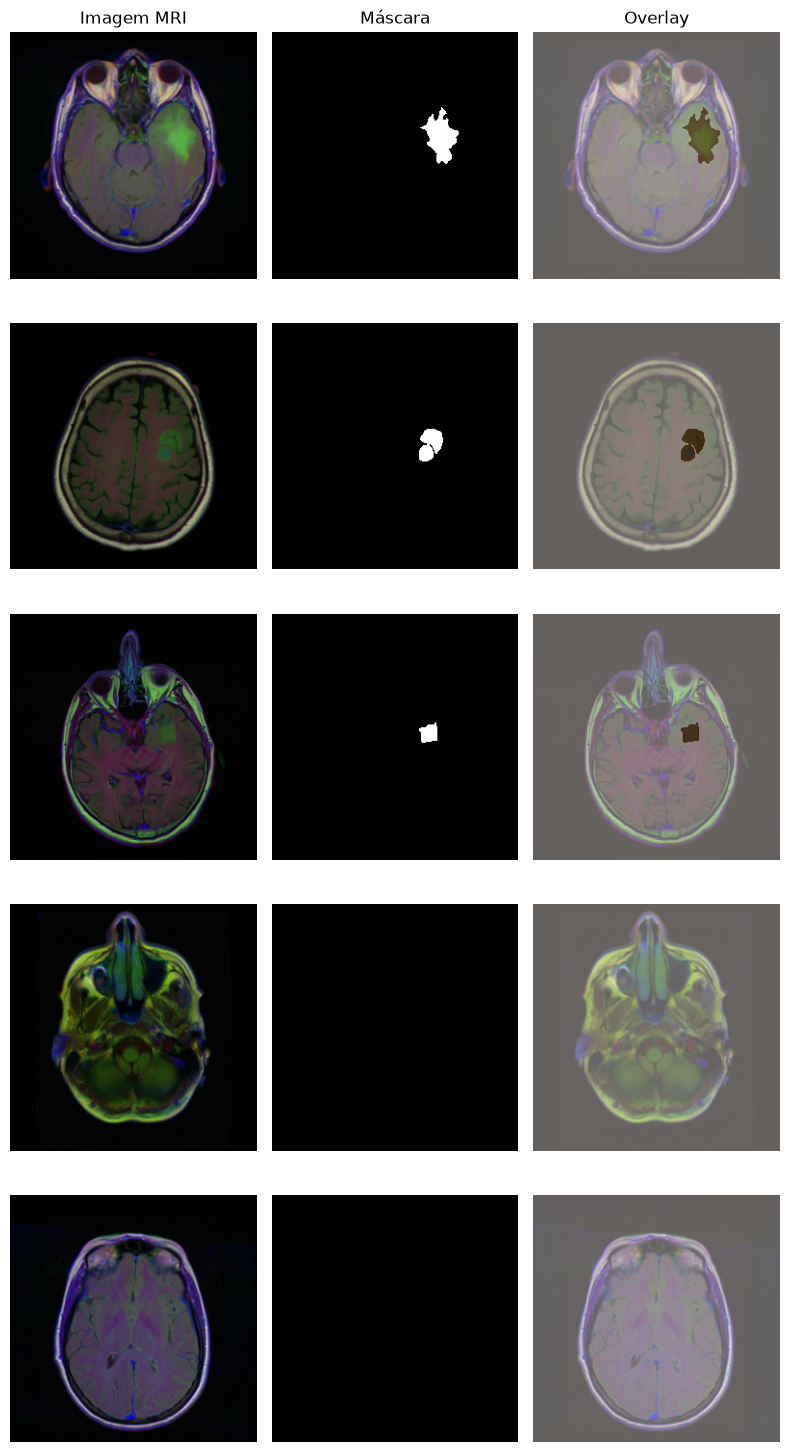

In [4]:
def carregar_par(row):
    img = Image.open(PROJECT_ROOT / row.image_path).convert("RGB")
    mask = Image.open(PROJECT_ROOT / row.mask_path).convert("L")
    return np.array(img), np.array(mask)

exemplos_tumor = manifest[manifest.has_tumor].sample(3, random_state=1)
exemplos_sem = manifest[~manifest.has_tumor].sample(2, random_state=1)
exemplos = pd.concat([exemplos_tumor, exemplos_sem])

fig, axes = plt.subplots(len(exemplos), 3, figsize=(8, 3 * len(exemplos)))
for i, (_, row) in enumerate(exemplos.iterrows()):
    img, mask = carregar_par(row)
    axes[i, 0].imshow(img); axes[i, 0].set_title("Imagem MRI" if i == 0 else ""); axes[i, 0].axis("off")
    axes[i, 1].imshow(mask, cmap="gray"); axes[i, 1].set_title("Máscara" if i == 0 else ""); axes[i, 1].axis("off")
    axes[i, 2].imshow(img); axes[i, 2].imshow(mask, cmap="Reds", alpha=0.4)
    axes[i, 2].set_title("Overlay" if i == 0 else ""); axes[i, 2].axis("off")
fig.tight_layout()
plt.show()


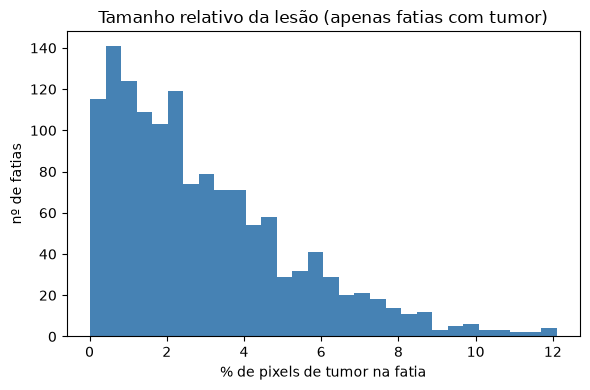

In [5]:
# Distribuição do tamanho relativo do tumor (fração de pixels) nas fatias com tumor:
# mostra que, mesmo entre casos positivos, a lesão costuma ocupar uma pequena fração da imagem
# -- por isso BCE isolado tende a ser insuficiente (classe minoritária) e Dice Loss ajuda.
plt.figure(figsize=(6, 4))
plt.hist(manifest[manifest.has_tumor].tumor_pixel_ratio * 100, bins=30, color="steelblue")
plt.xlabel("% de pixels de tumor na fatia")
plt.ylabel("nº de fatias")
plt.title("Tamanho relativo da lesão (apenas fatias com tumor)")
plt.tight_layout()
plt.show()


## Etapa 2 — Pré-processamento

- **Redimensionamento:** 256×256 → **128×128** (equilíbrio entre custo computacional em CPU
  e preservação de detalhes suficiente para segmentar a lesão). Imagem: interpolação bilinear;
  máscara: interpolação **nearest-neighbor** (para não introduzir valores intermediários que
  quebrariam a binariedade 0/1).
- **Normalização:** cada canal é normalizado com a média/desvio-padrão calculados a partir de
  uma amostra do **conjunto de treino** (evita vazamento de estatísticas do teste).
- **Aumento de dados (somente treino):** flip horizontal/vertical e rotação aleatória (±15°),
  para melhorar a generalização e mitigar o conjunto de treino relativamente pequeno
  (~2.700 fatias de 77 pacientes).


In [6]:
cfg_path = OUTPUTS / "config.json"
if cfg_path.exists():
    cfg = json.load(open(cfg_path))
    mean, std = tuple(cfg["mean"]), tuple(cfg["std"])
    print("Config de treino carregada de outputs/config.json")
else:
    from utils import compute_mean_std
    mean, std = compute_mean_std(splits["train"], image_size=128)
mean, std


Config de treino carregada de outputs/config.json


((0.09524113684892654, 0.0840621367096901, 0.08780882507562637),
 (0.1369909793138504, 0.12283788621425629, 0.13166500627994537))

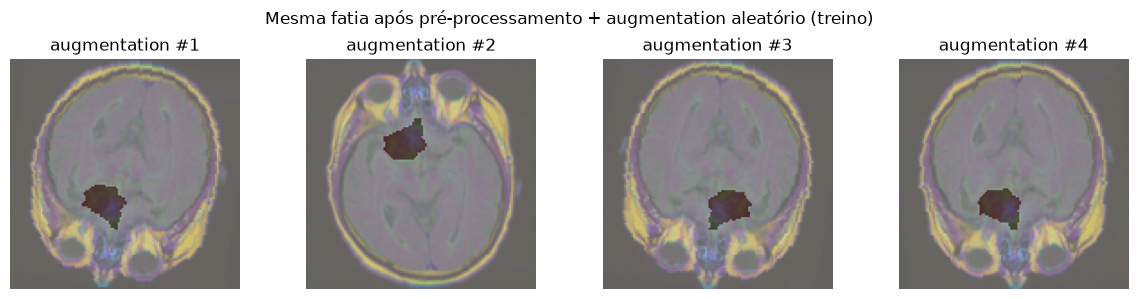

In [7]:
# Demonstração do pipeline de pré-processamento + augmentation em uma mesma fatia
amostra = manifest[manifest.has_tumor].iloc[0]
ds_demo = BrainMRISegmentationDataset(pd.DataFrame([amostra]), image_size=128, augment=True, mean=mean, std=std)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    img_t, mask_t = ds_demo[0]
    img_show = denormalize(img_t, mean, std).permute(1, 2, 0).numpy()
    axes[i].imshow(img_show)
    axes[i].imshow(mask_t.squeeze(0).numpy(), cmap="Reds", alpha=0.4)
    axes[i].set_title(f"augmentation #{i+1}")
    axes[i].axis("off")
fig.suptitle("Mesma fatia após pré-processamento + augmentation aleatório (treino)")
fig.tight_layout()
plt.show()


## Etapa 3 — Construção do modelo

**U-Net compacta** (≈1,9M parâmetros): 4 níveis de downsampling (encoder) + bottleneck +
4 níveis de upsampling (decoder) com *skip connections*, `Dropout2d` no bottleneck para
regularização. Saída: 1 canal de **logits** (tumor vs. fundo).

**Função de perda — BCE + Dice (combinada):**

$$\mathcal{L} = 0.5 \cdot \text{BCEWithLogits}(\hat{y}, y) + 0.5 \cdot \left(1 - \text{Dice}(\hat{y}, y)\right)$$

- **BCE** fornece gradiente estável pixel a pixel;
- **Dice** lida melhor com o forte desbalanceamento entre fundo e tumor (classe minoritária,
  como visto no histograma da Etapa 1) — é a métrica/perda padrão em segmentação médica.


In [8]:
model = UNet(base_ch=16, dropout=0.1)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parâmetros treináveis: {n_params:,}")

x = torch.randn(1, 3, 128, 128)
with torch.no_grad():
    y = model(x)
print("Entrada:", tuple(x.shape), "-> Saída (logits):", tuple(y.shape))


Parâmetros treináveis: 1,942,577


Entrada: (1, 3, 128, 128) -> Saída (logits): (1, 1, 128, 128)


## Etapa 4 — Treinamento e validação

**Hiperparâmetros:** tamanho de imagem 128×128, batch 32, otimizador Adam (lr=5e-4,
weight_decay=1e-4), `ReduceLROnPlateau` (baseado no Dice de validação), até 40 épocas com
**early stopping** (paciência de 10 épocas) para conter overfitting. Regularização:
`Dropout2d` no bottleneck, weight decay, augmentation e early stopping.

**Ajuste importante feito durante o experimento:** numa primeira rodada, o critério de
"melhor checkpoint" era o Dice médio de validação sobre **todas** as fatias — mas ~65% das
fatias não têm tumor, e uma fatia vazia acertada trivialmente (predição vazia) já contribui
com Dice ≈ 1. Isso inflava a métrica e escolhia um checkpoint que não segmentava bem o tumor
de fato. A correção aplicada foi calcular o Dice de seleção/early stopping **apenas nas
fatias de validação que contêm tumor**, além de aumentar o peso da Dice Loss (`bce_weight=0.3`)
e adicionar `pos_weight=3.0` ao BCE para dar mais importância aos pixels de tumor (raros:
~1% dos pixels do dataset, como visto no histograma da Etapa 1).

O treino completo (CPU) foi executado via script (`src/train.py`), pois demanda dezenas de
minutos — tempo inviável para reexecutar a cada abertura deste notebook. A seguir são
carregados o histórico de treino e as curvas geradas por essa execução. Para reproduzir do
zero: `python src/train.py`.

### Resultado do treinamento


Treino executado por 38 épocas (early stopping incluso).
Melhor Dice de validação (todas as fatias): 0.8340
Melhor Dice de validação (só fatias com tumor, critério de seleção): 0.7660


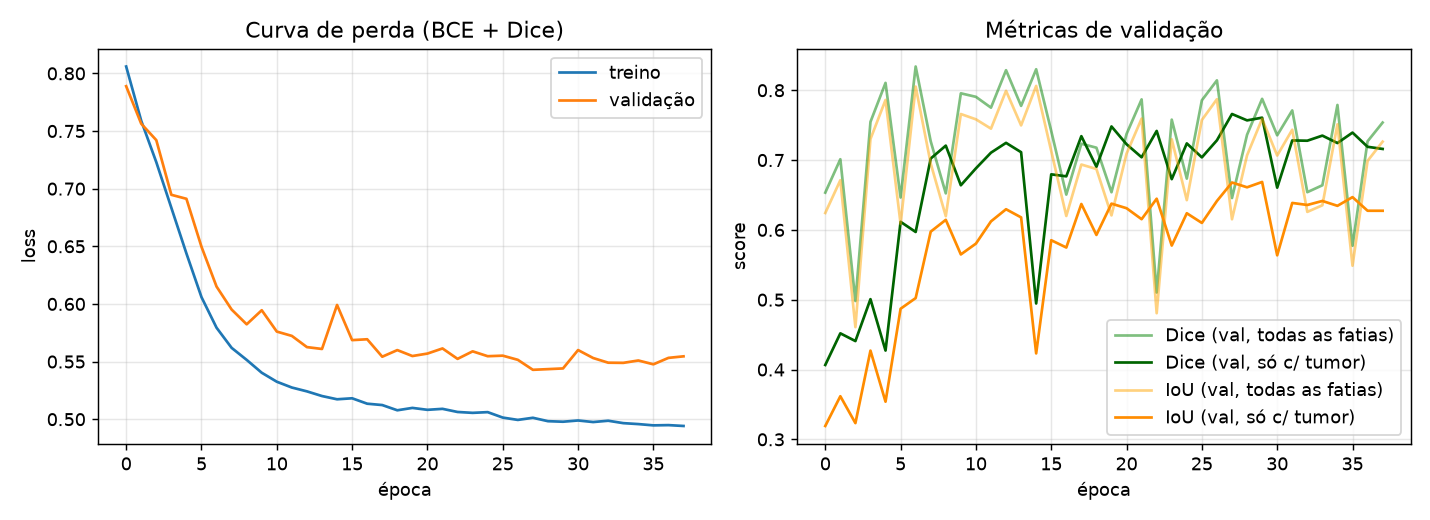

In [9]:
hist_path = OUTPUTS / "history.json"
curves_path = OUTPUTS / "figures" / "training_curves.png"

if hist_path.exists():
    history = json.load(open(hist_path))
    n_epochs_run = len(history["train_loss"])
    print(f"Treino executado por {n_epochs_run} épocas (early stopping incluso).")
    print(f"Melhor Dice de validação (todas as fatias): {max(history['val_dice']):.4f}")
    if "val_dice_tumor" in history:
        print(f"Melhor Dice de validação (só fatias com tumor, critério de seleção): {max(history['val_dice_tumor']):.4f}")
else:
    print("history.json não encontrado -- rode `python src/train.py` primeiro.")

if curves_path.exists():
    from IPython.display import Image as IPImage, display
    display(IPImage(filename=str(curves_path)))


**Leitura das curvas:** a perda de treino e validação caindo juntas (sem abertura de
"gap" crescente) indica ausência de overfitting severo; caso a perda de validação estabilize
ou suba enquanto a de treino continua caindo, seria sinal de overfitting — situação em que o
early stopping interrompe o treino no melhor ponto de validação (checkpoint salvo em
`outputs/checkpoints/best_model.pt`).


## Etapa 5 — Avaliação e interpretação

Métricas calculadas no **conjunto de teste** (17 pacientes nunca vistos no treino/validação):
**Dice coefficient** e **IoU** (Intersection over Union), a partir de predições binarizadas
(threshold 0.5 sobre a saída sigmoide).

São reportadas duas visões:
- **Geral** (todas as fatias de teste, incluindo as que não têm tumor);
- **Somente fatias com tumor** (mais informativa: fatias vazias inflam Dice/IoU médios com
  acertos triviais quando o modelo também prediz "vazio").

### Resultado no conjunto de teste


In [10]:
from IPython.display import display

ckpt_path = OUTPUTS / "checkpoints" / "best_model.pt"
metrics_df = None

if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location="cpu")
    cfg = ckpt["config"]
    model = UNet(base_ch=cfg["base_ch"], dropout=0.0)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    test_df = pd.read_csv(OUTPUTS / "split_test.csv")
    test_ds = BrainMRISegmentationDataset(test_df, cfg["image_size"], augment=False, mean=ckpt["mean"], std=ckpt["std"])
    test_loader = torch.utils.data.DataLoader(test_ds, batch_size=cfg["batch_size"], shuffle=False)

    loss_fn = BCEDiceLoss(bce_weight=cfg["bce_weight"], pos_weight=cfg.get("pos_weight"))
    overall = evaluate(model, test_loader, loss_fn, torch.device("cpu"), desc="teste")

    tumor_df = test_df[test_df.has_tumor].reset_index(drop=True)
    tumor_ds = BrainMRISegmentationDataset(tumor_df, cfg["image_size"], augment=False, mean=ckpt["mean"], std=ckpt["std"])
    tumor_loader = torch.utils.data.DataLoader(tumor_ds, batch_size=cfg["batch_size"], shuffle=False)
    tumor_only = evaluate(model, tumor_loader, loss_fn, torch.device("cpu"), desc="teste (c/ tumor)")

    metrics_df = pd.DataFrame([
        {"conjunto": "teste (todas as fatias)", **overall},
        {"conjunto": "teste (só fatias com tumor)", **tumor_only},
    ])
else:
    print("Checkpoint não encontrado -- rode `python src/train.py` primeiro.")

print("\n=== MÉTRICAS NO CONJUNTO DE TESTE ===")
if metrics_df is not None:
    display(metrics_df)


teste:   0%|          | 0/17 [00:00<?, ?it/s]

teste:   6%|▌         | 1/17 [00:00<00:05,  2.82it/s]

teste:  12%|█▏        | 2/17 [00:00<00:04,  3.28it/s]

teste:  18%|█▊        | 3/17 [00:00<00:04,  3.46it/s]

teste:  24%|██▎       | 4/17 [00:01<00:03,  3.51it/s]

...

teste (c/ tumor):  67%|██████▋   | 4/6 [00:01<00:00,  3.19it/s]

teste (c/ tumor):  83%|████████▎ | 5/6 [00:01<00:00,  3.23it/s]

teste (c/ tumor): 100%|██████████| 6/6 [00:01<00:00,  4.03it/s]


=== MÉTRICAS NO CONJUNTO DE TESTE ===


,conjunto,loss,dice,iou,pixel_acc
0,teste (todas as fatias),0.525504,0.644851,0.612157,0.995465
1,teste (só fatias com tumor),0.165612,0.798750,0.692993,0.991671


### Avaliação qualitativa: máscara predita sobreposta à imagem original

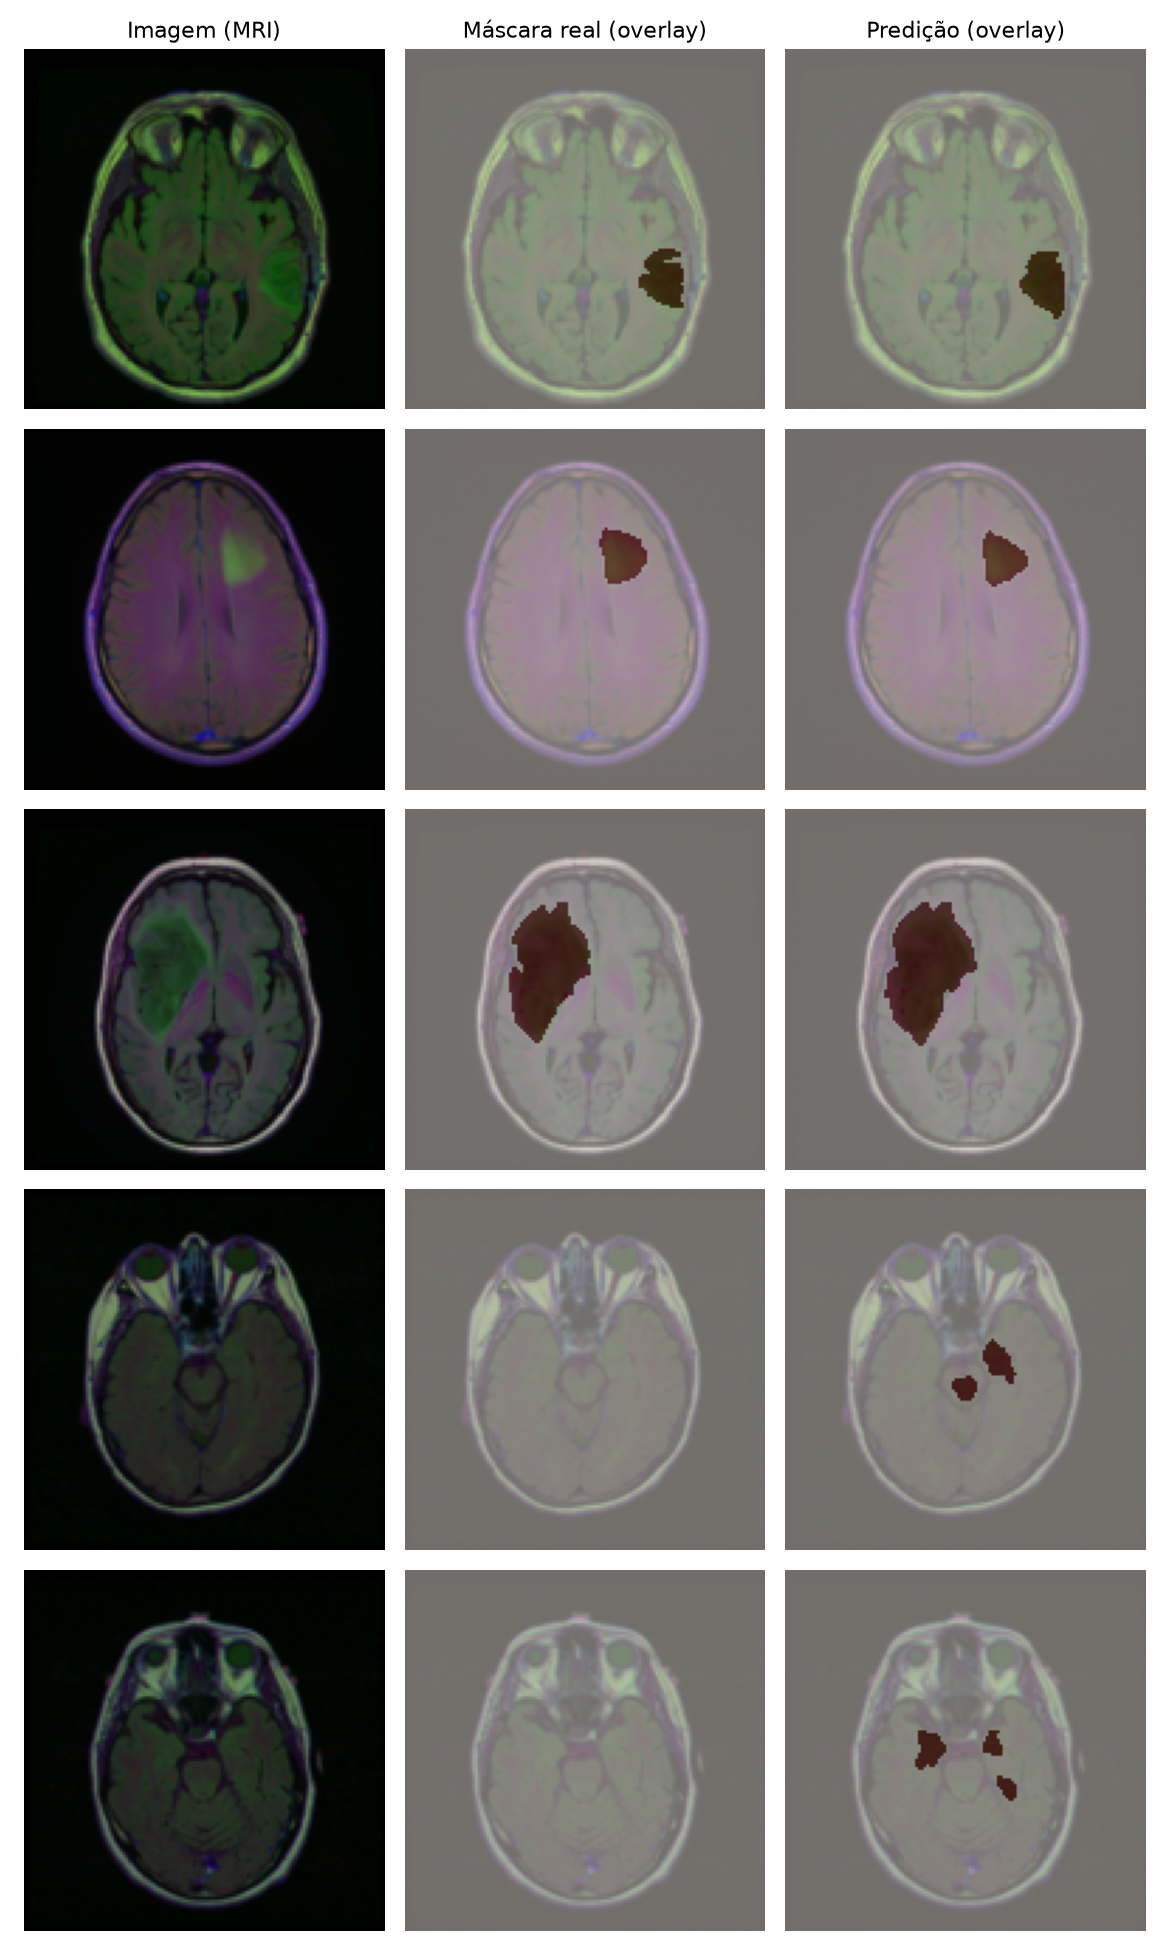

In [11]:
from utils import plot_prediction_grid

chosen_tumor = tumor_df.sample(min(3, len(tumor_df)), random_state=0)
chosen_empty = test_df[~test_df.has_tumor].sample(min(2, len(test_df[~test_df.has_tumor])), random_state=0)
chosen = pd.concat([chosen_tumor, chosen_empty])
vis_ds = BrainMRISegmentationDataset(chosen, cfg["image_size"], augment=False, mean=ckpt["mean"], std=ckpt["std"])

samples = []
with torch.no_grad():
    for i in range(len(vis_ds)):
        image, mask = vis_ds[i]
        logits = model(image.unsqueeze(0))
        pred = (torch.sigmoid(logits) > 0.5).float().squeeze(0)
        samples.append((image, mask, pred))

plot_prediction_grid(samples, OUTPUTS / "figures" / "test_predictions_notebook.png", mean=ckpt["mean"], std=ckpt["std"])
from IPython.display import Image as IPImage, display
display(IPImage(filename=str(OUTPUTS / "figures" / "test_predictions_notebook.png")))


### Interpretação e limitações

- O modelo consegue localizar razoavelmente bem lesões de tamanho médio/grande, com bordas
  mais suaves que as anotações manuais (esperado, dado o downsampling para 128×128).
- Fatias com lesões muito pequenas ou baixo contraste tendem a ser as mais difíceis
  (Dice mais baixo nesses casos) — coerente com o histograma da Etapa 1, que mostra que
  muitas lesões ocupam uma fração pequena da imagem.
- Em fatias **sem** tumor, o modelo por vezes prediz pequenas regiões falso-positivas,
  concentradas numa mesma área anatômica (próxima à base do crânio/lobo temporal) — indício de
  que o modelo aprendeu, em parte, um viés posicional de onde tumores costumam aparecer no
  dataset, em vez de basear a decisão só em textura/contraste local. Isso é coerente com o
  `pos_weight` usado no BCE (que aumenta a sensibilidade a pixels de tumor, à custa de mais
  falsos positivos) e explica por que o Dice **geral** (0,64) ficou mais baixo que o Dice
  **nas fatias com tumor** (0,80): o Dice geral penaliza esses falsos positivos em fatias que
  deveriam ficar totalmente vazias.
- Por isso a métrica **"só fatias com tumor"** é a mais representativa da capacidade real de
  localizar e delimitar a lesão quando ela de fato existe.
- **Limitações do experimento:** treino em CPU (sem GPU disponível), resolução reduzida
  (128×128 em vez dos 256×256 originais) e número de épocas limitado por tempo de execução.
- **Possíveis melhorias:** treinar em GPU com resolução original, usar um encoder pré-treinado
  (ex. ResNet/EfficientNet como *backbone* da U-Net), aplicar pós-processamento morfológico
  nas predições e explorar perdas adicionais (Focal Loss, Tversky Loss) para casos de lesões
  muito pequenas.
